# RNA velocity in the Ouroboros Sphere 


It is possible to have scVelo infer RNA velocity and to output the velocity vectors onto the sphere. 

Unfourtunately scVelo is a tricky package that doesn't always play nice with other packages, so you will need a new, specific environment for this purpose. 

Also note that scVelo requires the presence of spliced and unspliced counts in your adata.layers().

For more information on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]

### Velocity environment 

**Dependencies**
*Note these versions are just the ones I tested it with - other versions may also work*
- pandas
- anndata
- scvelo = 0.2.3
- scanpy = 1.8.2


To create run: 
```bash
conda create -n velocity_env python=3.10
conda activate velocity_env

mamba install -c conda-forge -c bioconda "scvelo>=0.2.3" "scanpy>=1.8.2" pandas anndata scikit-learn "numpy<1.24" "pynndescent>=0.5.13"
```

In [2]:
import anndata as ad
import importlib_resources as resources
import scanpy as sc
import pandas as pd
import scvelo as scv
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.transform import Rotation as R

# Step 1: Read in your filtered, normalized dataset 

In [3]:
# Read in test dataset - subsetted to existing features
## Replace with path to your adata object 
adata = ad.read_h5ad('/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi/ouroboros/data/neurogen_example.h5ad')

In [4]:
# Make sure your adata has been filtered and normalized - see single cell best practices for more information on how to do this:
## [https://www.sc-best-practices.org/preamble.html]

adata.X = adata.layers['raw_counts'].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers['logged_counts'] = adata.X.copy()
sc.pp.scale(adata)
adata.layers['scaled_logged_counts'] = adata.X.copy()

We found that cell cycle velocity comes out most cleanly when using the Ouroboros feature set, rather than with all genes as is depicted in the scVelo tutorial. This is likely because dataset may have multiple trajectories (i.e. differentiaiton and cell cycle) and focusing in on only cell cycle informative genes helps to isolate the signal from just the cell cycle. 

In [5]:
#Replace with path to your installation of Ouroboros 
ouroboros_path = '/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi'
feature_set = pd.read_csv(f'{ouroboros_path}/ouroboros/data/SHAP_feature_set.csv')
feature_set = feature_set.feature_set.tolist()

# Subset to only include feature set genes 
adata_subset = adata[:, adata.var_names.isin(feature_set)].copy()

Next you will read in the z_df with the latent space embeddings output when you ran Ouroboros 

In [6]:
# Replace with the path to your z_df 
z_df_path = '/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi/docs/output_example/ouroboros_embeddings_pseudotimes.csv'

z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,dormancy_depth
Unnamed: 0,,,,,,
CTGATCCGTCAGACTT_SRX17782706,0.997972,-0.060443,-0.019959,S,0.777424,NaN
GCCCGAAAGTAGTGCG_SRX17782704,0.062366,-0.522792,0.850176,G1,0.030358,NaN
CCGATGGTCTGATGGT_SRX17782709,0.298726,-0.716041,0.630910,G2M,0.973088,NaN
CCTCTCCGTTATGTCG_SRX17782704,-0.785088,0.544524,-0.295178,G0,NaN,-0.232186
AGCGTATGTCTACACA_SRX17782704,-0.179392,0.719529,-0.670892,G1-G0 transition,NaN,-0.194541
...,...,...,...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.941296,0.337502,0.007401,G0,NaN,-0.241869
ACTGTCCAGTCCTACA_SRX17782709,-0.341617,0.156724,0.926680,G1,0.160973,NaN
TCGCTCAAGCACTCAT_SRX17782706,-0.567939,0.764667,-0.304516,G0,0.405928,-0.161059


If you plan on using a robinson projection to display your data in 2D, I highly recommend rotating the sphere so the cycle pole is the true north-south axis - it will look much more comprehensible in 2D. 

We can't access Ouroboros functions here because scVelo conflicts with some of the Ouroboros dependencies, so I have included the base code for the find_cycle_pole() and rotate_north() function here for you to run. 

In [ ]:
# If you retrained the VAE because of missing genes, your cell cycle point will have changed (if you did not just skip this step) - find it like so: 

# You will need to read in the retrained reference embeddings in your ouroboros output folder: 
ref_embed = pd.read_csv('output_example/reference_embeddings.csv')

def fit_great_circle(points):
    """ Fit a great circle around the sphere capturing variation along a set of points
    points = set of points"""
    # Perform PCA to find the plane
    pca = PCA(n_components=3)
    pca.fit(points)
    normal_vector = pca.components_[2]  # Normal vector to the plane
    plane_vectors = pca.components_[:2]  # Basis vectors for the plane

    # Generate great circle points
    t = np.linspace(0, 2 * np.pi, 100)
    circle_points = (
        np.outer(np.cos(t), plane_vectors[0]) +
        np.outer(np.sin(t), plane_vectors[1])
    )
    return circle_points,normal_vector



def find_cycle_pole(z_df, ref_embed, phase_category = 'KNN_phase'):
    """ Find a point on the sphere's surface that represents the centre of the cycling cells
    z_df: embedded points including cycling cells to find the centre of
    ref_embed: reference embedded points 
    phase_category: name of the columns with phase labels to parse (needs to have G1/S/G2M)"""
    cyc = z_df[z_df[phase_category].isin(['G2M', 'S', 'G1'])]
    points = cyc[['dim1', 'dim2', 'dim3']].values
    # Fit the great circle
    great_circle, normal_vector = fit_great_circle(points)
    top_center = normal_vector / np.linalg.norm(normal_vector)

    # Little test to make sure top point is in the middle of cycling cells and not G0 cells
    cyc = ref_embed[ref_embed['phase'].isin(['G2M', 'S', 'G1'])]
    points = cyc[['dim1', 'dim2', 'dim3']].values

    ## Get centroid of G1, S, G2M cells
    cyc_centroid = np.mean(points, axis=0)
    ## Get centroid of G0 cells
    g0 = ref_embed[ref_embed['phase'] == 'G0']
    g0_points = g0[['dim1', 'dim2', 'dim3']].values
    g0_centroid = np.mean(g0_points, axis=0)
    ## Compute dot products
    dot_cyc = np.dot(top_center, cyc_centroid)
    dot_g0 = np.dot(top_center, g0_centroid)
    ## If top_center aligns more with G0, flip it
    if dot_g0 > dot_cyc:
        top_center = -top_center
    return top_center

# You may then also want to find the retrained cycle pole
cycle_pole = find_cycle_pole(z_df, ref_embed)



In [7]:
# To rotate your points and set the cycle pole as the north-south axis, define and run the rotate_north() function 

def rotate_north(z_df, reference_CC_pole_point = [0.86202236, 0.24824865, 0.44191636]):
    """Rotate the cell cycle pole to be north pole
    Note: will replace dim1, dim2, dim3 in z_df"""
    new_df = z_df.copy()
    # Reference point
    reference_CC_pole_point = np.array(reference_CC_pole_point)
    target_vector = reference_CC_pole_point / np.linalg.norm(reference_CC_pole_point)
    # Default North Pole
    north_pole = np.array([0, 0, 1])

    # Compute rotation axis and angle
    rotation_axis = np.cross(target_vector, north_pole)
    if np.linalg.norm(rotation_axis) > 1e-8:  # Avoid division by zero for near-parallel vectors
        rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
    rotation_angle = np.arccos(np.clip(np.dot(target_vector, north_pole), -1.0, 1.0))

    # Create the rotation
    rotation = R.from_rotvec(rotation_axis * rotation_angle)

    # Extract coordinates
    coordinates = new_df[['dim1', 'dim2', 'dim3']].values

    # Apply the rotation
    rotated_coordinates = rotation.apply(coordinates)

    # Update z_df with the rotated coordinates
    new_df[['dim1', 'dim2', 'dim3']] = rotated_coordinates
    return new_df

# If you did not retrain the VAE call it like this: 
rotated_z_df = rotate_north(z_df)

# If you did retrain the VAE, include the updated cycle pole point:
#rotate_north(z_df, cycle_pole = cycle_pole)

In [8]:
# Write rotated z_df to a csv so we can use it for 2D robinson projection plotting later
rotated_z_df.to_csv('output_example/north_rotated_example_embeddings.csv')

ScVelo typically works on the dimensions of a UMAP embedding in adata.obsm. To make it accept the latent space instead, we just have to trick it by setting adata.obsm['X_umap'] to be our latent space instead of a UMAP embedding, and then scVelo can run as it normally would. 

In [9]:
latent_space = rotated_z_df[['dim1', 'dim2', 'dim3']].values

# Set X_umap to be our latent space instead of a UMAP 

adata.obsm['X_umap'] = latent_space

Normalized count data: spliced, unspliced.
computing neighbors
    finished (0:00:20) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


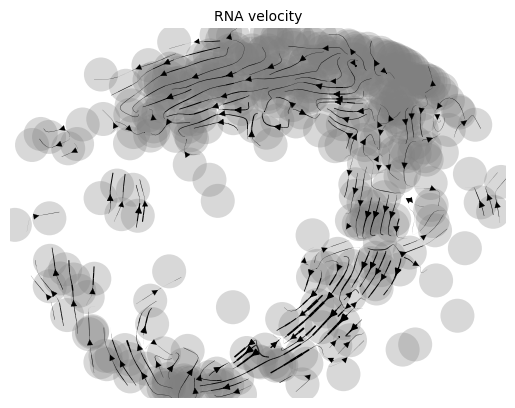

In [10]:
# Then scVelo can be run as it normally would be on the adata
## For more info on scVelo see their tutorial: [https://scvelo.readthedocs.io/en/stable/getting_started.html]
vel = adata.copy()
scv.pp.moments(vel, n_neighbors = 20, use_highly_variable = False)
scv.tl.velocity(vel, mode='stochastic')
scv.tl.velocity_graph(vel)
scv.pl.velocity_embedding_stream(vel, basis='umap', title = 'RNA velocity')

We can then take the velocity vectors straight from the adata itself: 

In [11]:
vel_df = pd.DataFrame(vel.obsm['velocity_umap'], columns = ['dim1', 'dim2', 'dim3'], index = vel.obs.index)

vel_df.to_csv('output_example/example_velocity_df.csv')

We can't access Ouroboros functions like plot_sphere() here because scVelo conflicts with some of the Ouroboros dependencies. 

So, to plot these vectors onto the sphere, you can save the velocity dataframe to a csv, and load them into a new notebook using the ouroboros_env kernal. 

Here you would use your ouroboros_env to run this code: 

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns
import pandas as pd

In [2]:
# Read in your latent space embeddings - if you rotated before calling velocity make sure you read in the rotated coordinates 
# Replace with the path to your z_df 
z_df_path = '/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi/docs/output_example/north_rotated_example_embeddings.csv'

z_df = pd.read_csv(z_df_path)
z_df = z_df.set_index('Unnamed: 0')
z_df

,dim1,dim2,dim3,KNN_phase,cell_cycle_pseudotime,dormancy_depth
Unnamed: 0,,,,,,
CTGATCCGTCAGACTT_SRX17782706,0.509849,-0.201015,0.836449,S,0.777424,NaN
GCCCGAAAGTAGTGCG_SRX17782704,-0.625056,-0.720759,0.299685,G1,0.030358,NaN
CCGATGGTCTGATGGT_SRX17782709,-0.292811,-0.886395,0.358562,G2M,0.973088,NaN
CCTCTCCGTTATGTCG_SRX17782704,-0.206861,0.711044,-0.672030,G0,NaN,-0.232186
AGCGTATGTCTACACA_SRX17782704,0.384595,0.881948,-0.272496,G1-G0 transition,NaN,-0.194541
...,...,...,...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,-0.512673,0.460938,-0.724363,G0,NaN,-0.241869
ACTGTCCAGTCCTACA_SRX17782709,-0.987645,-0.029321,0.153940,G1,0.160973,NaN
TCGCTCAAGCACTCAT_SRX17782706,-0.126240,0.891869,-0.434319,G0,0.405928,-0.161059


In [3]:
# Read in your velocity vectors for those embeddings 
vel_df = pd.read_csv('/projects/steiflab/research/hmacdonald/total_RNA/Ouroboros_pypi/docs/output_example/example_velocity_df.csv')
vel_df = vel_df.set_index('Unnamed: 0')
vel_df

,dim1,dim2,dim3
Unnamed: 0,,,
CTGATCCGTCAGACTT_SRX17782706,-0.012927,-0.042134,0.002993
GCCCGAAAGTAGTGCG_SRX17782704,-0.001204,0.001784,-0.009132
CCGATGGTCTGATGGT_SRX17782709,0.003245,0.007865,0.011364
CCTCTCCGTTATGTCG_SRX17782704,-0.018776,0.008893,0.007032
AGCGTATGTCTACACA_SRX17782704,-0.014279,0.001047,-0.006167
...,...,...,...
TTGTGTTAGCGACAGT_SRX17782709,0.006116,-0.009562,-0.026262
ACTGTCCAGTCCTACA_SRX17782709,0.000653,0.005371,-0.022979
TCGCTCAAGCACTCAT_SRX17782706,0.010963,-0.013681,-0.042206


In [ ]:
# Plot the sphere as before, but give the velocity vector df to the parameter velocity to have it plot the vectors too 
fig = obo.plot_sphere(z_df, colour_by='KNN_phase', velocity=vel_df, show=False, savefig = 'output_example/example_sphere_with_velocity.html')

You can also use cartopy to make a robinson projection, and can add the velocity vectors to this. We have provided a function to do so: 

In [ ]:
def plot_robinson_projection_with_velocity(
    z_df, 
    colour_by, 
    velocity_df=None, 
    palette=None, 
    ref_df=None,
    central_longitude=80, 
    title="", 
    alpha=0.7,
    scale=10
):
    """
    Plot a Robinson projection of 3D spherical coordinates with optional RNA velocity vectors and color encoding.

    This function visualizes points projected from 3D spherical coordinates (`dim1`, `dim2`, `dim3`) 
    onto a 2D Robinson projection, color-coded by a metadata column (`colour_by`). 
    It supports both continuous and categorical color mappings and can overlay RNA velocity vectors 
    and reference points.

    Parameters
    ----------
    z_df : pandas.DataFrame
        DataFrame containing 3D Cartesian coordinates (columns: 'dim1', 'dim2', 'dim3') and a 
        metadata column to color by.
    
    colour_by : str
        Name of the column in `z_df` to use for coloring points. Can be continuous or categorical.
    
    velocity_df : pandas.DataFrame, optional
        DataFrame with velocity vectors in 2D spherical space (columns: 'dim1', 'dim2').
        These will be overlaid as quiver arrows.
    
    palette : str or dict, optional
        For categorical data: a dictionary mapping category labels to colors.
        For continuous data: a matplotlib colormap name or colormap object.
        If `colour_by` is 'cell_cycle_pseudotime' or 'dormancy_depth', a default colormap is used.
    
    ref_df : pandas.DataFrame, optional
        Optional reference DataFrame with 3D coordinates and a 'putative_phase_transition' column 
        to overlay as transparent background points. 
    
    central_longitude : int, default=80
        Longitude to center the Robinson projection.
    
    title : str, optional
        Title of the plot.
    
    alpha : float, default=0.7
        Transparency for primary scatter points.

    scale : float, default=10
        Scaling factor for velocity arrows. This will be dataset-dependant, so play with it until you get something that looks nice. 

    Behavior
    --------
    - Continuous variables are visualized using a colormap.
    - Categorical variables use a defined or generated color palette.
    """


In [5]:
import cartopy.crs as ccrs

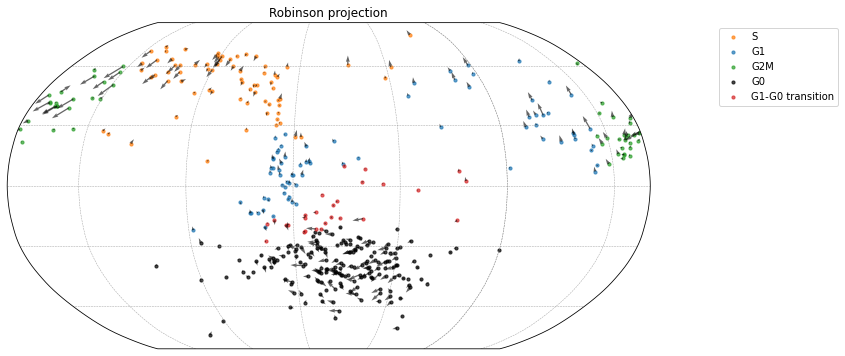

In [ ]:
obo.plot_robinson_projection(
    z_df, 
    colour_by = 'KNN_phase',
    velocity_df=vel_df, 
    palette=None, 
    ref_df=None,
    central_longitude=80, 
    title="Robinson projection", 
    alpha=0.7,
    scale=3
    
)